In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Read CSV Data

In [3]:
# read in csv data from Kaggle & NOAA Physical Sciences Laboratory 
elnino = pd.read_csv("elnino.csv") # predictor variables
nino_ind = pd.read_csv("nino34.csv") # target data

In [4]:
elnino.head()

,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,.,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,.,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,.,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,.,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,.,25.3,23.19


In [5]:
nino_ind.head()

,Date,NINA34 missing value -99.99 https://psl.noaa.gov/data/timeseries/month/
0,1870-01-01,-1.00
1,1870-02-01,-1.20
2,1870-03-01,-0.83
3,1870-04-01,-0.81
4,1870-05-01,-1.27


# Clean Predictor Data

In [7]:
# remove leading and trailing spaces in column names
elnino.columns = elnino.columns.str.strip()
print(elnino.columns.tolist())

['Observation', 'Year', 'Month', 'Day', 'Date', 'Latitude', 'Longitude', 'Zonal Winds', 'Meridional Winds', 'Humidity', 'Air Temp', 'Sea Surface Temp']


In [8]:
# replace '.' with NaN
elnino = elnino.replace('.', np.nan)

# convert numeric columns where possible
for col in elnino.columns:
    try:
        elnino[col] = pd.to_numeric(elnino[col])
    except:
        pass  # leave non-numeric columns unchanged

# drop Day and Date
elnino = elnino.drop(columns=["Day", "Date", "Observation"])

# # remove data outside of El Niño 3.4 bounds
# elnino = elnino[(elnino['Latitude'] <= -5) | (elnino['Latitude'] >= 5)]
# elnino = elnino[(elnino['Longitude'] >= -170) | (elnino['Longitude'] <= -120)]

# elnino.head()

Above, we commented out the removal of observations with latitudes and longitudes outside the bounds of El Niño 3.4 data. We wanted to test whether the predictions would estimate better with data only coming from the bounds of 3.4 data; however, we found the opposite to be true. Inclusion of data out of the El Niño 3.4 bounds observes more accurate predictions (as we tested with out actual v. prediction graphs). Thus, we decided to keep our predictor data inlusive of all bounds of El Niño.

In [10]:
# elnino.info()

In [11]:
# group by Year and Month, compute means
agg_elnino = elnino.groupby(["Year", "Month"], as_index=False).mean()

# remove humidity -- many NaNs
agg_elnino = agg_elnino.drop(columns=["Humidity"])

# fix Year
agg_elnino.Year = agg_elnino.Year + 1900

In [12]:
agg_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000


In [13]:
agg_elnino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              211 non-null    int64  
 1   Month             211 non-null    int64  
 2   Latitude          211 non-null    float64
 3   Longitude         211 non-null    float64
 4   Zonal Winds       211 non-null    float64
 5   Meridional Winds  211 non-null    float64
 6   Air Temp          211 non-null    float64
 7   Sea Surface Temp  208 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 13.3 KB


# Clean Target Data

In [15]:
print(nino_ind.columns.tolist())

['Date', '   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/']


In [16]:
# add Year and Month columns to merge predictor and target data
nino_ind['Year'] = nino_ind['Date'].str.split('-').str[0].astype(int)
nino_ind['Month'] = nino_ind['Date'].str.split('-').str[1].astype(int)

In [17]:
# drop Date columns
nino_ind = nino_ind.drop(columns=["Date"])

In [18]:
# rename indices column
nino_ind = nino_ind.rename(columns={"   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/": "NINA34"})

# reorder columns
nino_ind = nino_ind[['Year', 'Month', 'NINA34']]

In [19]:
nino_ind.head()

,Year,Month,NINA34
0,1870,1,-1.00
1,1870,2,-1.20
2,1870,3,-0.83
3,1870,4,-0.81
4,1870,5,-1.27


In [20]:
nino_ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1872 entries, 0 to 1871
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    1872 non-null   int64  
 1   Month   1872 non-null   int64  
 2   NINA34  1872 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 44.0 KB


# Merge Predictor & Target Data

In [22]:
# merge the data with the El Niño data
clean_elnino = agg_elnino.merge(nino_ind, on=["Year","Month"])

clean_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp,NINA34
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667,0.09
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429,-0.23
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333,-0.12
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129,-0.11
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000,0.10


In [23]:
# drop rows with NaN
clean_elnino = clean_elnino.dropna()

In [24]:
clean_elnino.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 210
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              208 non-null    int64  
 1   Month             208 non-null    int64  
 2   Latitude          208 non-null    float64
 3   Longitude         208 non-null    float64
 4   Zonal Winds       208 non-null    float64
 5   Meridional Winds  208 non-null    float64
 6   Air Temp          208 non-null    float64
 7   Sea Surface Temp  208 non-null    float64
 8   NINA34            208 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 16.2 KB


In [25]:
# add classification target variable if we want to do classification
class_list = []

for index in clean_elnino.NINA34:
    if (index >= 0.05) | (index <= -0.05):
        class_list.append(1)
    else:
        class_list.append(0)

clean_elnino['Event'] = class_list

In [26]:
clean_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp,NINA34,Event
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667,0.09,1
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429,-0.23,1
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333,-0.12,1
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129,-0.11,1
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000,0.10,1


We added an Event column that identifies whether an El Niño or La Niña event occured (1) or not (0) within that Month and Year. After training our data with a Random Forest Classifier model, the model was not successful as it always predicted an El Niño or La Niña event. Thus, we will not be using that column further and only utilized it for testing a Random Forest Classifier model. 

# Linear Regression Model

In [28]:
# define model features
features = ['Zonal Winds', 'Meridional Winds', 'Air Temp', 'Sea Surface Temp']

# define X, y
X = clean_elnino[features]
y = clean_elnino['NINA34']

In [29]:
# split training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [30]:
# calculate MSE and r2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.28007525815411194
R² Score: 0.5484354911328657


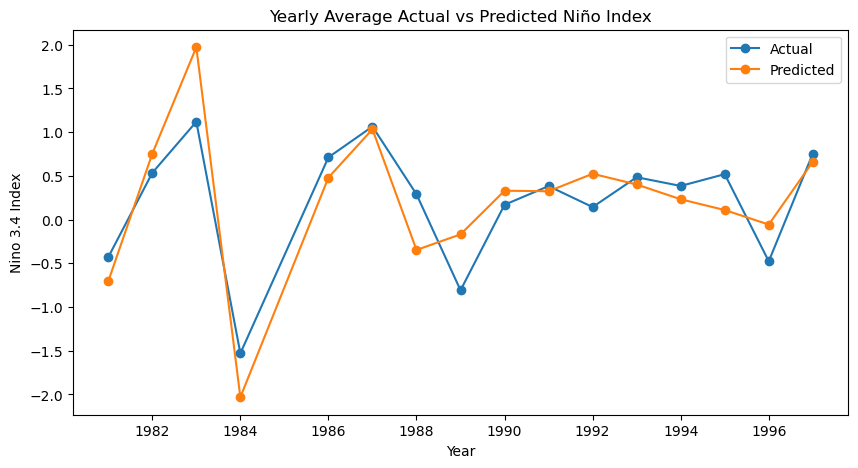

In [31]:
# plot time series actual v. predicted Niño index
results = pd.DataFrame({
    "Year": clean_elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred
})

yearly = results.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly["Year"], yearly["Actual"], marker='o', label="Actual")
plt.plot(yearly["Year"], yearly["Predicted"], marker='o', label="Predicted")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Yearly Average Actual vs Predicted Niño Index")

plt.legend()
plt.show()

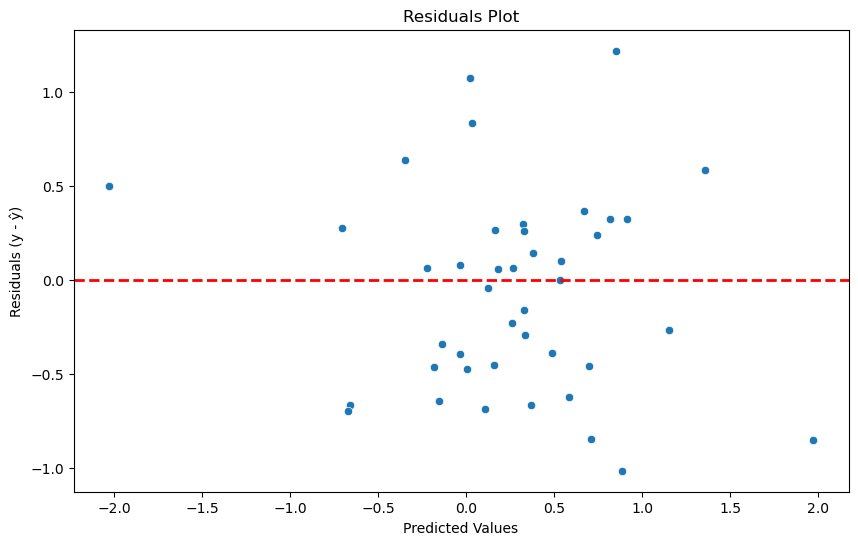

In [32]:
# plot residuals
residuals = y_test - y_pred

plt.figure(figsize = (10, 6))
sns.scatterplot(x = y_pred, y = residuals)
plt.axhline(0, color = 'red', linestyle = '--', linewidth = 2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals Plot")
plt.show()

# Random Forest Regressor Model

In [34]:
# fit random forest regression model
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [35]:
# calculate MSE and r2 score
mse2 = mean_squared_error(y_test, y_pred_rf)
r2_2 = r2_score(y_test, y_pred_rf)

print("Mean Squared Error:", mse2)
print("R² Score:", r2_2)

Mean Squared Error: 0.2826085209523808
R² Score: 0.5443511190291999


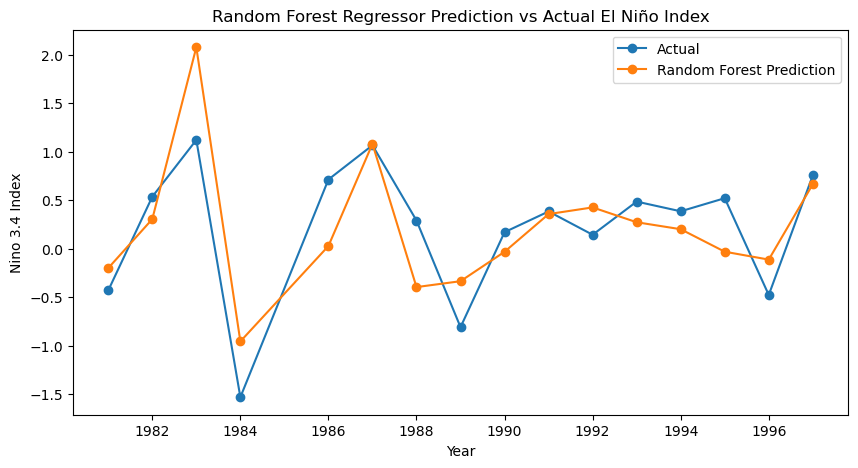

In [36]:
# plot time series actual v. predicted Niño index
results_rf = pd.DataFrame({
    "Year": clean_elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred_rf
})

results_rf = results_rf.sort_values("Year")

# Yearly average to reduce noise
yearly_rf = results_rf.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly_rf["Year"], yearly_rf["Actual"], marker='o', label="Actual")
plt.plot(yearly_rf["Year"], yearly_rf["Predicted"], marker='o', label="Random Forest Prediction")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Random Forest Regressor Prediction vs Actual El Niño Index")

plt.legend()
plt.show()

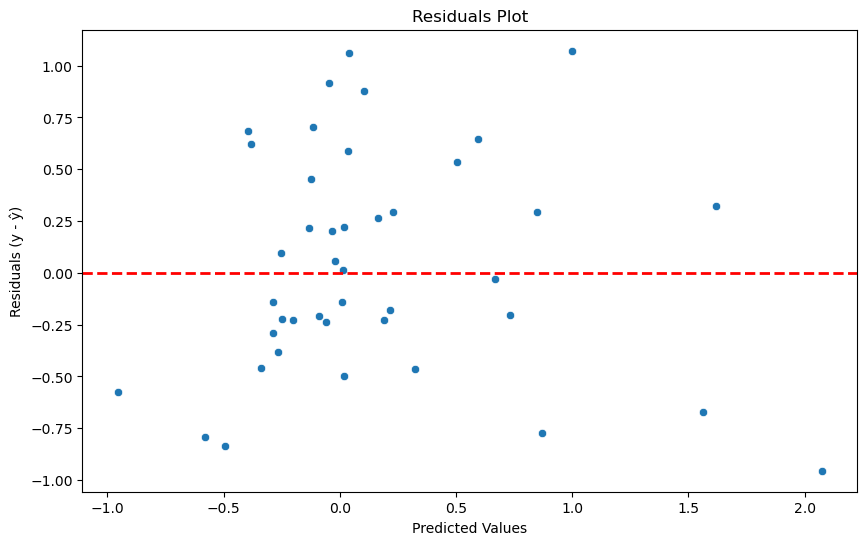

In [37]:
# plot residuals
residuals_rf = y_test - y_pred_rf

plt.figure(figsize = (10, 6))
sns.scatterplot(x = y_pred_rf, y = residuals_rf)
plt.axhline(0, color = 'red', linestyle = '--', linewidth = 2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals Plot")
plt.show()